# Exploratory Data Analysis: Global Power Plant Database

This notebook performs comprehensive exploratory data analysis on the Global Power Plant Database (GPPD) from the World Resources Institute.

## Objectives
- Load and inspect the raw dataset
- Analyze fuel type distributions
- Examine capacity distributions
- Identify top countries by installed capacity
- Visualize missing value patterns

In [17]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

%matplotlib inline

## 1. Load Dataset

In [18]:
data_path = Path.cwd().parent / 'data' / 'raw' / 'global_power_plant_database.csv'
df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset shape: {df.shape}")
print(f"Total power plants: {len(df):,}")
print(f"Total attributes: {df.shape[1]}")

Dataset shape: (34936, 36)
Total power plants: 34,936
Total attributes: 36


In [19]:
df.head(10)

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.00,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.00,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
5,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,58.77,54.42,42.71,59.72,46.12,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
6,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION
7,AFG,Afghanistan,Pul-e-Khumri Hydroelectric Power Plant Afghani...,GEODB0040537,6.00,35.9416,68.7100,Hydro,NaN,NaN,...,21.99,21.19,18.40,25.34,19.74,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
8,AFG,Afghanistan,Sarobi Dam Hydroelectric Power Plant Afghanistan,GEODB0040535,22.00,34.5865,69.7757,Hydro,NaN,NaN,...,123.23,82.87,69.15,93.83,80.00,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
9,ALB,Albania,Bistrica 1,WRI1002169,27.00,39.9116,20.1047,Hydro,NaN,NaN,...,105.17,75.26,79.50,105.45,88.45,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

## 2. Basic Statistics

In [21]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [22]:
total_capacity_tw = df['capacity_mw'].sum() / 1e6
print(f"Total global capacity: {total_capacity_tw:.2f} TW")
print(f"Mean plant capacity: {df['capacity_mw'].mean():.2f} MW")
print(f"Median plant capacity: {df['capacity_mw'].median():.2f} MW")
print(f"Number of countries: {df['country'].nunique()}")

Total global capacity: 5.71 TW
Mean plant capacity: 163.36 MW
Median plant capacity: 16.74 MW
Number of countries: 167


## 3. Fuel Type Distribution

In [23]:
fuel_counts = df['primary_fuel'].value_counts()
print("Plant count by fuel type:")
print(fuel_counts)

Plant count by fuel type:
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


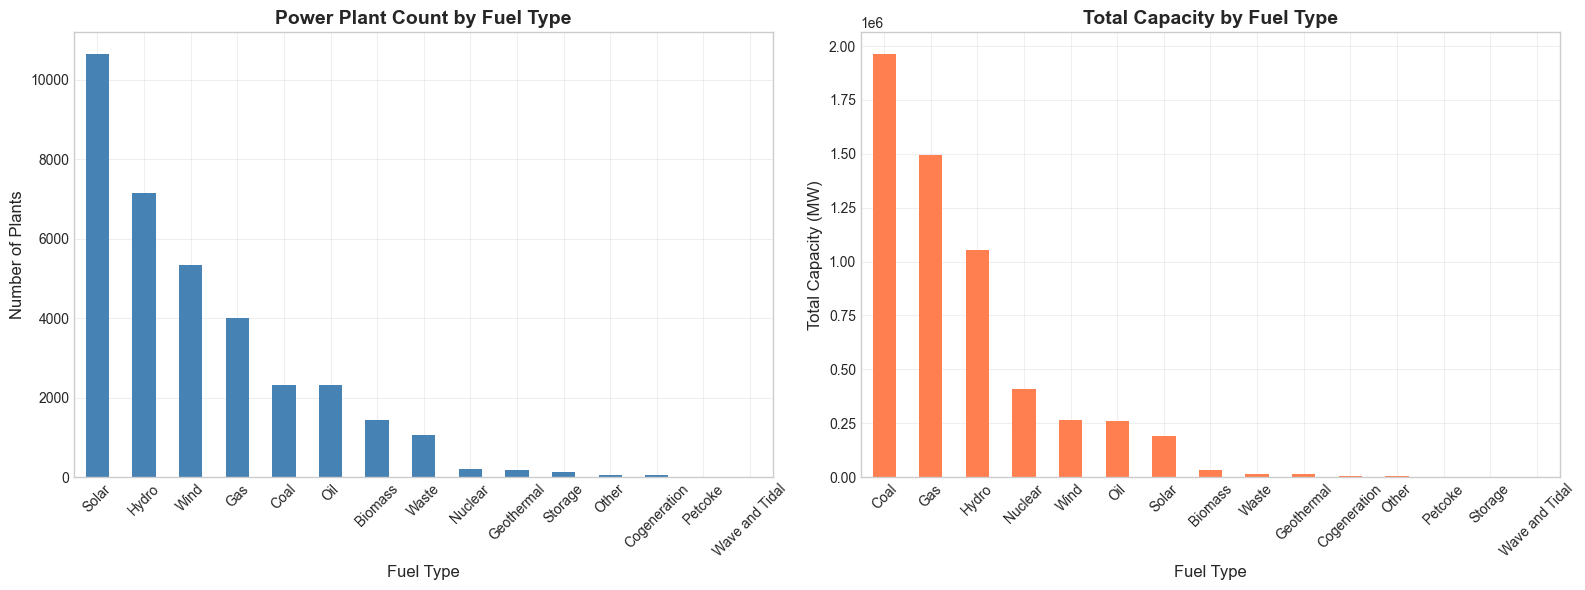

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fuel_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Power Plant Count by Fuel Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fuel Type', fontsize=12)
axes[0].set_ylabel('Number of Plants', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

fuel_capacity = df.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False)
fuel_capacity.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Total Capacity by Fuel Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fuel Type', fontsize=12)
axes[1].set_ylabel('Total Capacity (MW)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'fuel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Capacity Distribution

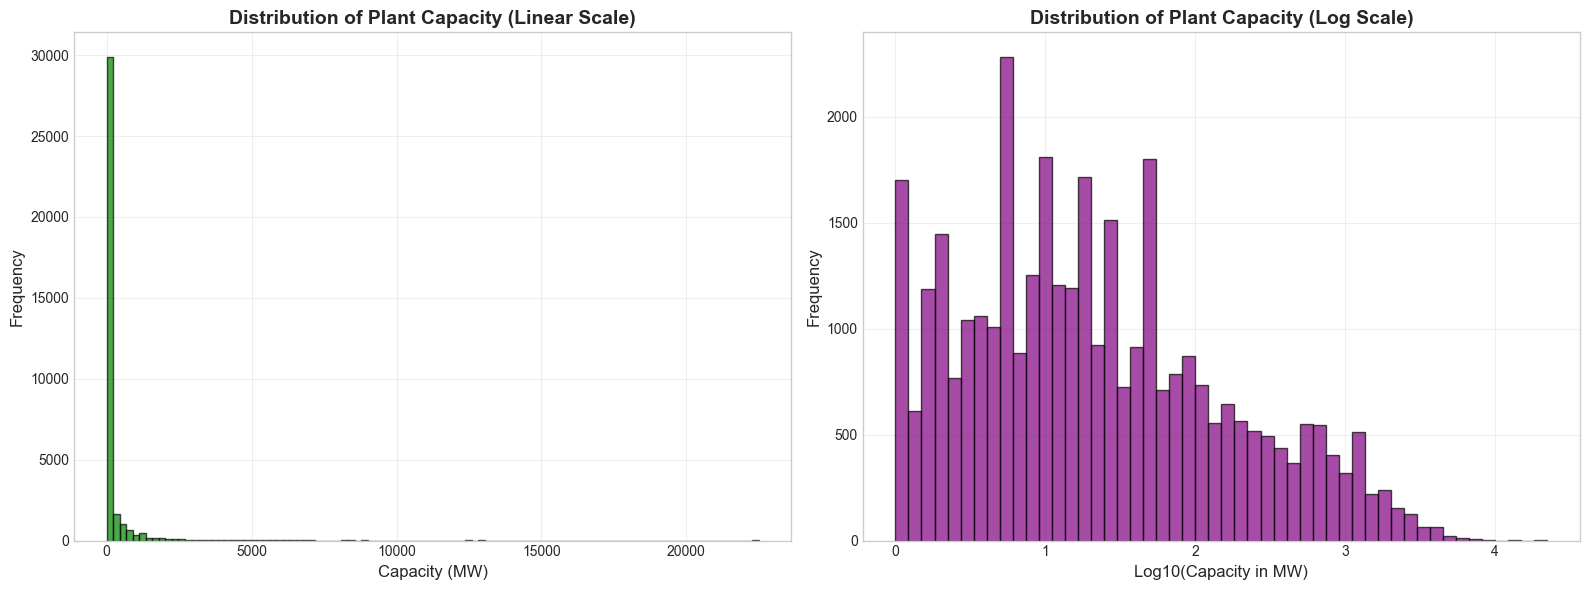

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['capacity_mw'], bins=100, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Capacity (MW)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Plant Capacity (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log10(df['capacity_mw'][df['capacity_mw'] > 0]), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Log10(Capacity in MW)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Plant Capacity (Log Scale)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'capacity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Countries by Installed Capacity

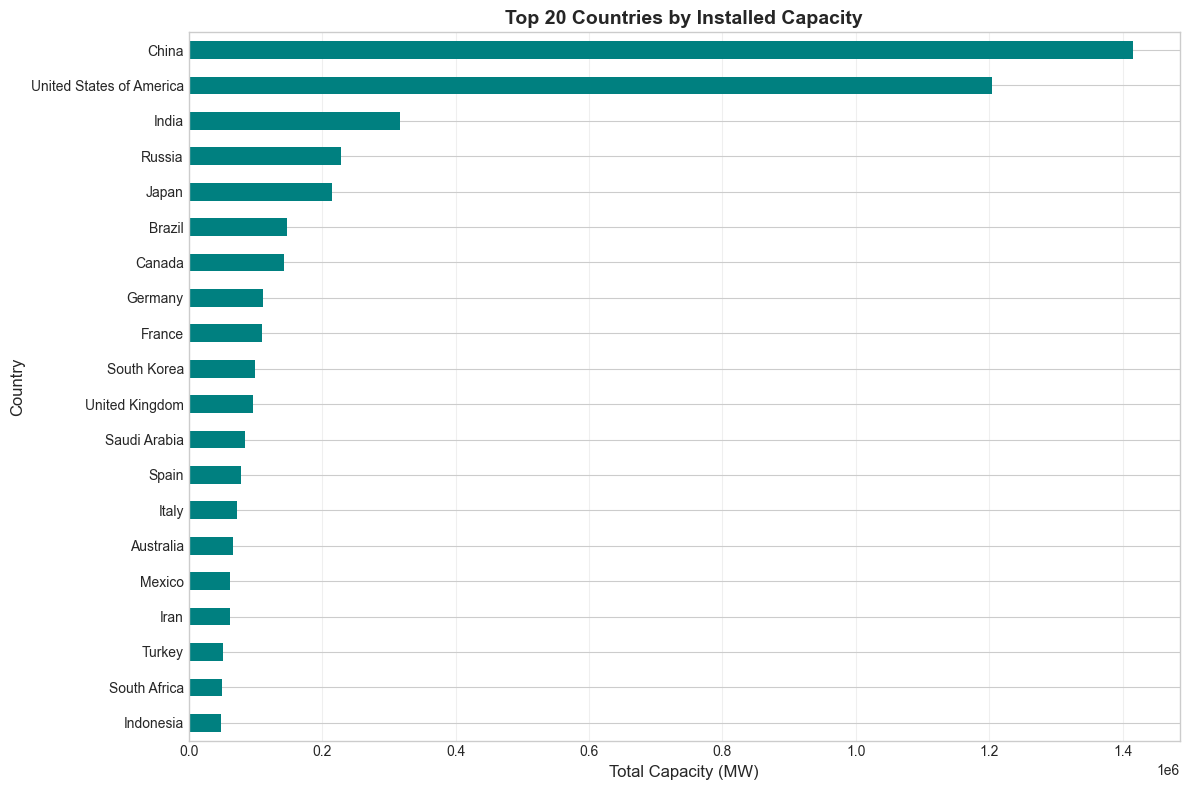

In [26]:
country_capacity = df.groupby('country_long')['capacity_mw'].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
country_capacity.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Total Capacity (MW)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 20 Countries by Installed Capacity', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'top_countries_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("\nTop 20 countries by installed capacity:")
for i, (country, capacity) in enumerate(country_capacity.items(), 1):
    print(f"{i:2d}. {country:30s}: {capacity:12,.0f} MW ({capacity/1000:8,.1f} GW)")


Top 20 countries by installed capacity:
 1. China                         :    1,415,067 MW ( 1,415.1 GW)
 2. United States of America      :    1,204,638 MW ( 1,204.6 GW)
 3. India                         :      316,089 MW (   316.1 GW)
 4. Russia                        :      228,220 MW (   228.2 GW)
 5. Japan                         :      215,366 MW (   215.4 GW)
 6. Brazil                        :      147,589 MW (   147.6 GW)
 7. Canada                        :      143,579 MW (   143.6 GW)
 8. Germany                       :      112,040 MW (   112.0 GW)
 9. France                        :      110,616 MW (   110.6 GW)
10. South Korea                   :       99,473 MW (    99.5 GW)
11. United Kingdom                :       97,155 MW (    97.2 GW)
12. Saudi Arabia                  :       84,342 MW (    84.3 GW)
13. Spain                         :       79,035 MW (    79.0 GW)
14. Italy                         :       73,095 MW (    73.1 GW)
15. Australia                     :

## 6. Missing Value Analysis

In [28]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})

print("Missing values by column:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing values by column:
                               Missing Count  Percentage
other_fuel3                            34844       99.74
other_fuel2                            34660       99.21
other_fuel1                            32992       94.44
generation_gwh_2013                    28519       81.63
generation_gwh_2014                    27710       79.32
generation_gwh_2015                    26733       76.52
generation_gwh_2016                    25792       73.83
generation_gwh_2017                    25436       72.81
generation_gwh_2018                    25299       72.42
generation_gwh_2019                    25277       72.35
generation_data_source                 23536       67.37
year_of_capacity_data                  20049       57.39
estimated_generation_gwh_2013          18816       53.86
wepp_id                                18702       53.53
estimated_generation_gwh_2014          18433       52.76
estimated_generation_gwh_2015          17886       51.20
commi

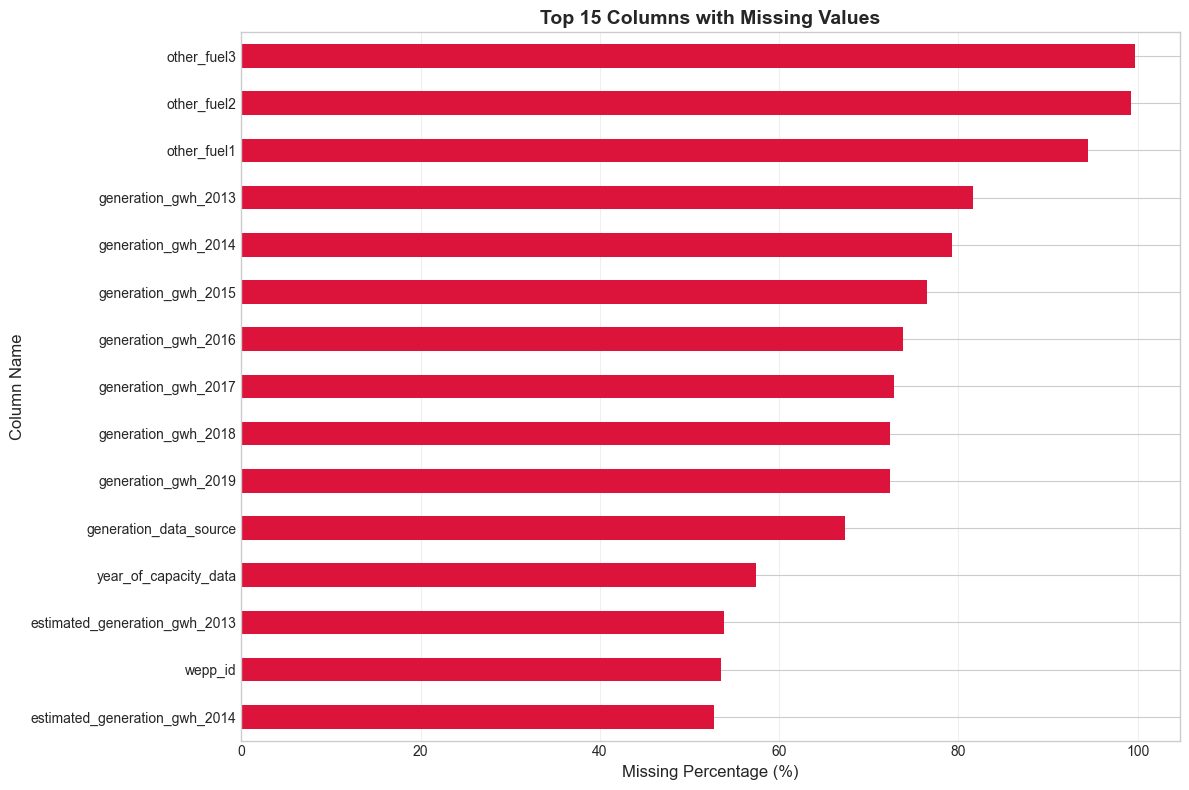

In [29]:
missing_top = missing_df[missing_df['Missing Count'] > 0].head(15)

fig, ax = plt.subplots(figsize=(12, 8))
missing_top['Percentage'].plot(kind='barh', ax=ax, color='crimson')
ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_ylabel('Column Name', fontsize=12)
ax.set_title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Geographic Distribution

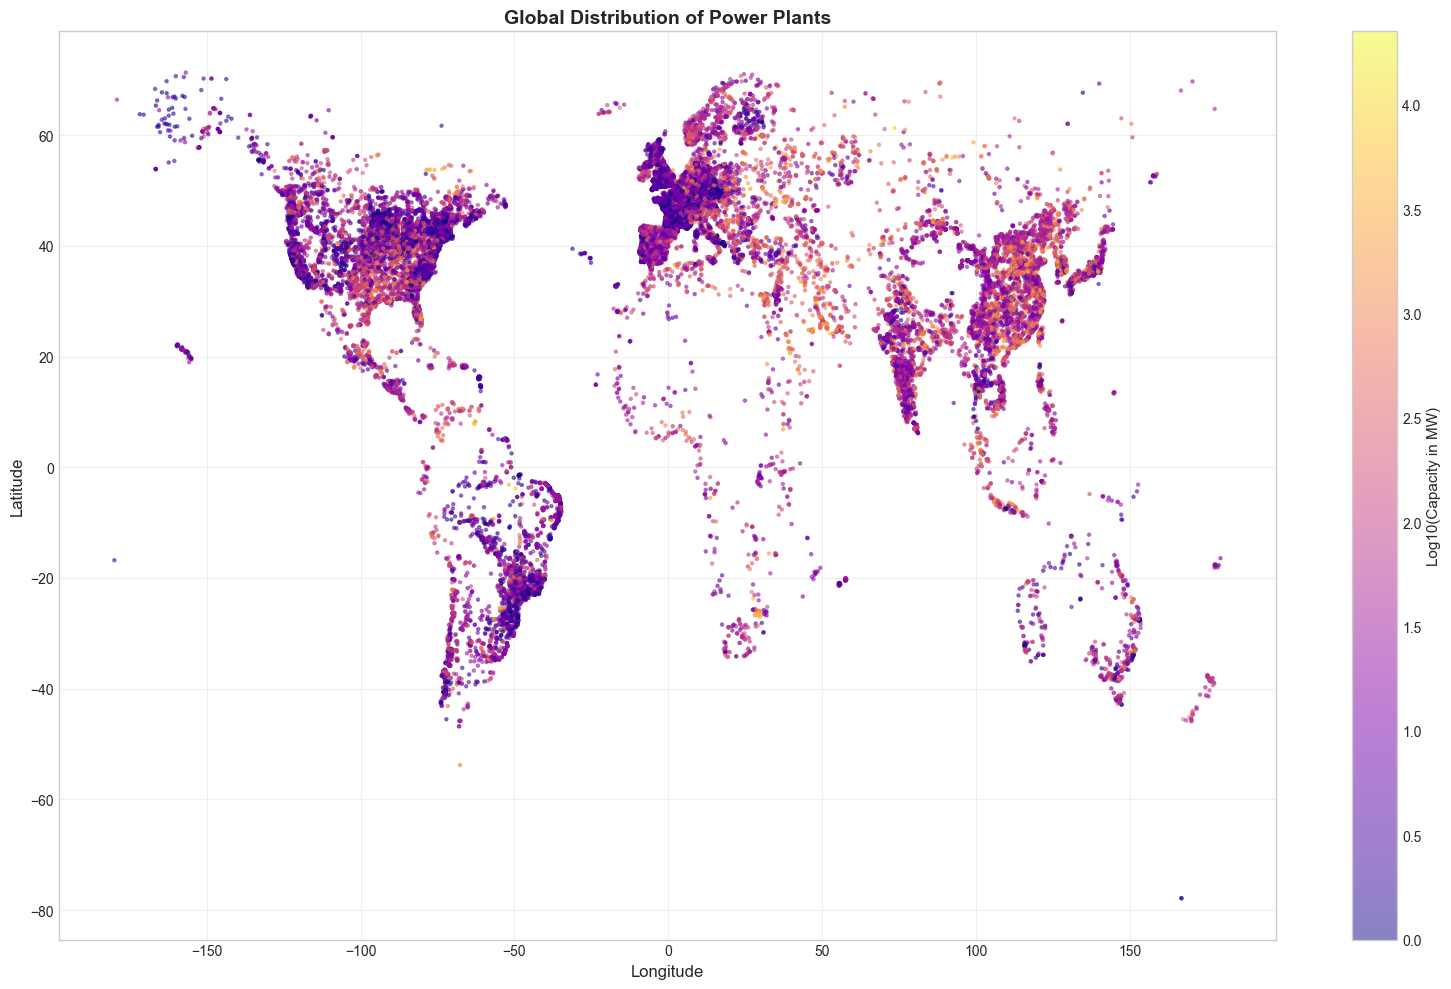

In [30]:
fig, ax = plt.subplots(figsize=(16, 10))

scatter = ax.scatter(df['longitude'], df['latitude'], 
                     c=np.log10(df['capacity_mw']), 
                     s=5, alpha=0.5, cmap='plasma')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Global Distribution of Power Plants', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Log10(Capacity in MW)', fontsize=11)

plt.tight_layout()
plt.savefig(Path.cwd().parent / 'figures' / 'geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generation Data Coverage

In [31]:
generation_coverage = df['estimated_generation_gwh_2017'].notna().sum()
generation_percent = (generation_coverage / len(df)) * 100

print(f"Plants with generation data: {generation_coverage:,} ({generation_percent:.1f}%)")
print(f"Plants without generation data: {len(df) - generation_coverage:,} ({100-generation_percent:.1f}%)")

Plants with generation data: 33,138 (94.9%)
Plants without generation data: 1,798 (5.1%)


In [32]:
generation_by_fuel = df.groupby('primary_fuel')['estimated_generation_gwh_2017'].agg(['count', 'sum', 'mean'])
generation_by_fuel['coverage_rate'] = (generation_by_fuel['count'] / df.groupby('primary_fuel').size() * 100).round(1)
generation_by_fuel = generation_by_fuel.sort_values('sum', ascending=False)

print("\nGeneration data by fuel type:")
print(generation_by_fuel)


Generation data by fuel type:
                count         sum          mean  coverage_rate
primary_fuel                                                  
Coal             2306  9653451.97   4186.232424           99.0
Gas              3947  6021909.55   1525.692817           98.7
Hydro            7156  3541440.61    494.891086          100.0
Nuclear           193  2902412.32  15038.405803           99.0
Wind             5343   689101.45    128.972759          100.0
Oil              2263   500807.68    221.302554           97.5
Solar           10665   347580.34     32.590749          100.0
Geothermal        158    60095.69    380.352468           83.6
Other              42    16527.46    393.510952           97.7
Waste            1065     8173.60      7.674742           99.7
Cogeneration        0        0.00           NaN            0.0
Biomass             0        0.00           NaN            0.0
Petcoke             0        0.00           NaN            0.0
Storage             0   

## Summary

This EDA revealed:

1. **Dataset Size**: ~35,000 power plants across 167 countries with ~5.7 TW total capacity
2. **Fuel Distribution**: Dominated by hydro, solar, wind, and coal plants
3. **Capacity Distribution**: Highly skewed with many small plants and few large ones
4. **Top Countries**: USA, China, and India lead in installed capacity
5. **Missing Data**: Generation estimates available for ~95% of plants
6. **Geographic Spread**: Global coverage with concentration in industrialized regions

Next steps: Feature engineering and capacity factor analysis